# 01 — Prikupljanje podataka i Fama-French faktorske izloženosti

Faza 1 + faza 2 projekta s kliznim prozorom.

1. Dohvati trenutačni univerzum Russell 1000 (iShares IWB CSV, uz vraćanje na
   Wikipedijinu tablicu sastavnica kad iShares blokira preuzimanje).
2. Preuzmi dnevne prilagođene zaključne cijene u obnovljivu parquet predmemoriju
   po dionici, preuzorkuj na kraj mjeseca i izračunaj mjesečne + viškove prinosa.
3. Dohvati Fama-French petfaktorsku mjesečnu datoteku.
4. Za svaki klizni prozor treniranja (dug 60 mjeseci, ponovno procjenjivanje svakih 12 mjeseci)
   procijeni petfaktorske izloženosti po dionici metodom OLS i spremi ih kao dugi
   panel.

Izlazi u `data/processed/`:
- `monthly_returns.csv`, `excess_returns.csv`, `factors.csv`, `metadata.csv`
- `factor_exposures.csv` (dugi format sa stupcem `train_window`).


In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

from src.data import preprocess
from src.factors import estimate_betas_all_windows
from src.backtest import generate_rolling_windows
from src.utils import (
    FIGURES_DIR,
    PROCESSED_DATA_DIR,
    PROJECT_END,
    PROJECT_START,
    ensure_dirs,
    set_seed,
)

ensure_dirs()
set_seed()


## 1.1 Dohvati Russell 1000, preuzmi cijene, izgradi mjesečne prinose


In [2]:
preprocessed = preprocess(start=PROJECT_START, end=PROJECT_END)
monthly_returns = preprocessed["monthly_returns"]
excess_returns = preprocessed["excess_returns"]
factors = preprocessed["factors"]
metadata = preprocessed["metadata"]

print("Veličina univerzuma nakon pretprocesiranja:", monthly_returns.shape[1])
print("Pokrivenost datuma:", monthly_returns.index.min().date(), "→", monthly_returns.index.max().date())
print("Oblik faktora:", factors.shape)
print("Neuspjela preuzimanja:", len(preprocessed["failed_downloads"]))


2026-06-04 20:47:57,233 ERROR $VGNT: possibly delisted; no price data found  (1d 2004-12-01 -> 2026-01-01) (Yahoo error = "Data doesn't exist for startDate = 1101877200, endDate = 1767243600")
2026-06-04 20:47:57,242 ERROR 
1 Failed download:
2026-06-04 20:47:57,242 ERROR ['VGNT']: possibly delisted; no price data found  (1d 2004-12-01 -> 2026-01-01) (Yahoo error = "Data doesn't exist for startDate = 1101877200, endDate = 1767243600")
2026-06-04 20:47:57,274 INFO Preuzeto 1/1 novih oznaka (1 neuspjelih dosad)
2026-06-04 20:47:57,942 WARNING 1 oznaka nije uspjelo preuzeti: VGNT


Veličina univerzuma nakon pretprocesiranja: 999
Pokrivenost datuma: 2005-01-31 → 2025-12-31
Oblik faktora: (252, 6)
Neuspjela preuzimanja: 1


Provjeri jednu dionicu i jedan niz faktora.


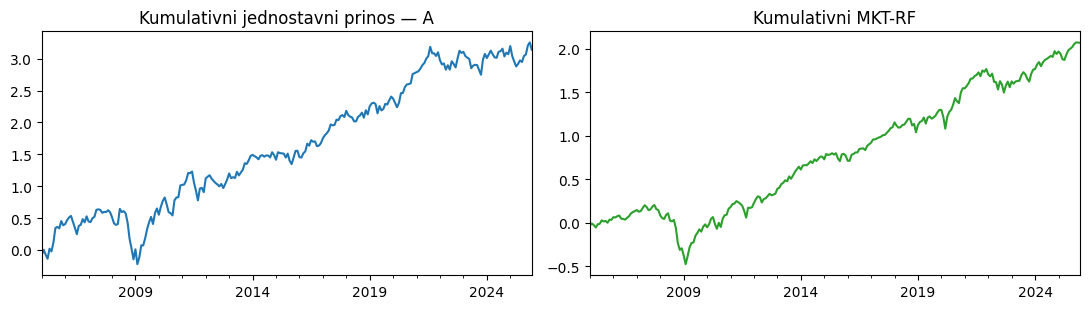

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
n_obs_per_ticker = monthly_returns.notna().sum(axis=0)
example_ticker = n_obs_per_ticker.idxmax()
monthly_returns[example_ticker].dropna().cumsum().plot(ax=axes[0], color="C0")
axes[0].set_title(f"Kumulativni jednostavni prinos — {example_ticker}")
axes[0].set_xlabel("")
factors["Mkt-RF"].cumsum().plot(ax=axes[1], color="C2")
axes[1].set_title("Kumulativni MKT-RF")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()


## 1.2 Klizni prozori i pokrivenost univerzuma po prozoru


In [4]:
windows = generate_rolling_windows(project_start=PROJECT_START, project_end=PROJECT_END)
print(f"{len(windows)} kliznih prozora generirano.")
for w in windows[:3]:
    print(w.label, w.train_start.date(), "→", w.train_end.date(),
          "| test", w.test_start.date(), "→", w.test_end.date())
print("...")
for w in windows[-2:]:
    print(w.label, w.train_start.date(), "→", w.train_end.date(),
          "| test", w.test_start.date(), "→", w.test_end.date())


16 kliznih prozora generirano.
2009-12 2005-01-31 → 2009-12-31 | test 2010-01-31 → 2010-12-31
2010-12 2006-01-31 → 2010-12-31 | test 2011-01-31 → 2011-12-31
2011-12 2007-01-31 → 2011-12-31 | test 2012-01-31 → 2012-12-31
...
2023-12 2019-01-31 → 2023-12-31 | test 2024-01-31 → 2024-12-31
2024-12 2020-01-31 → 2024-12-31 | test 2025-01-31 → 2025-12-31


2026-06-04 20:47:59,913 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-04 20:47:59,914 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


   train_window  n_eligible
0       2009-12         616
1       2010-12         637
2       2011-12         652
3       2012-12         669
4       2013-12         678
5       2014-12         685
6       2015-12         704
7       2016-12         716
8       2017-12         735
9       2018-12         765
10      2019-12         786
11      2020-12         815
12      2021-12         832
13      2022-12         845
14      2023-12         865
15      2024-12         889


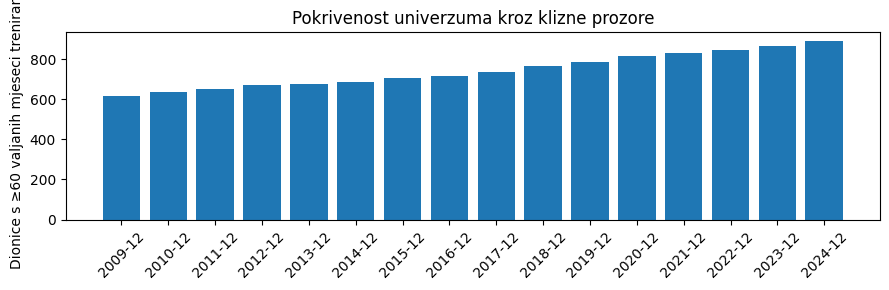

In [5]:
from src.utils import MIN_TRAINING_MONTHS

coverage_records = []
for window in windows:
    train_panel = monthly_returns.loc[window.train_start:window.train_end]
    eligible = (train_panel.notna().sum(axis=0) >= MIN_TRAINING_MONTHS).sum()
    coverage_records.append({"train_window": window.label, "n_eligible": int(eligible)})
coverage = pd.DataFrame(coverage_records)
print(coverage)

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(coverage["train_window"], coverage["n_eligible"], color="C0")
ax.set_ylabel("Dionice s ≥60 valjanih mjeseci treniranja")
ax.set_title("Pokrivenost univerzuma kroz klizne prozore")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_universe_coverage.png", dpi=150)
plt.show()


## 1.3 Fama-French faktorske izloženosti po prozoru


In [6]:
factor_exposures = estimate_betas_all_windows(
    excess_returns=excess_returns,
    factors=factors,
    windows=[w.as_tuple() for w in windows],
)
factor_exposures_path = PROCESSED_DATA_DIR / "factor_exposures.csv"
factor_exposures.to_csv(factor_exposures_path, index=False)
print("Faktorske izloženosti:", factor_exposures.shape, "→", factor_exposures_path)
factor_exposures.head()


Faktorske izloženosti: (11762, 11) → /Users/marinmestrovic/Desktop/personal/daozip/data/processed/factor_exposures.csv


,train_window,ticker,alpha,beta_mkt,beta_smb,beta_hml,beta_rmw,beta_cma,residual_vol,r_squared,n_obs
0,2009-12,A,0.016951,1.379125,0.538637,-1.021563,-1.520225,1.775913,0.076538,0.525967,60
1,2009-12,AA,-0.008995,2.085554,0.904369,-0.188863,1.116556,-0.637830,0.073703,0.678176,60
2,2009-12,AAON,0.010487,0.850390,0.555747,-0.260110,0.458402,0.643152,0.089361,0.191958,60
3,2009-12,AAPL,0.037604,1.750413,-0.404475,-0.905355,0.098397,-1.846580,0.090214,0.483093,60
4,2009-12,ABT,0.006289,0.194178,-0.488327,0.146438,-0.367814,0.204288,0.052083,0.077337,60


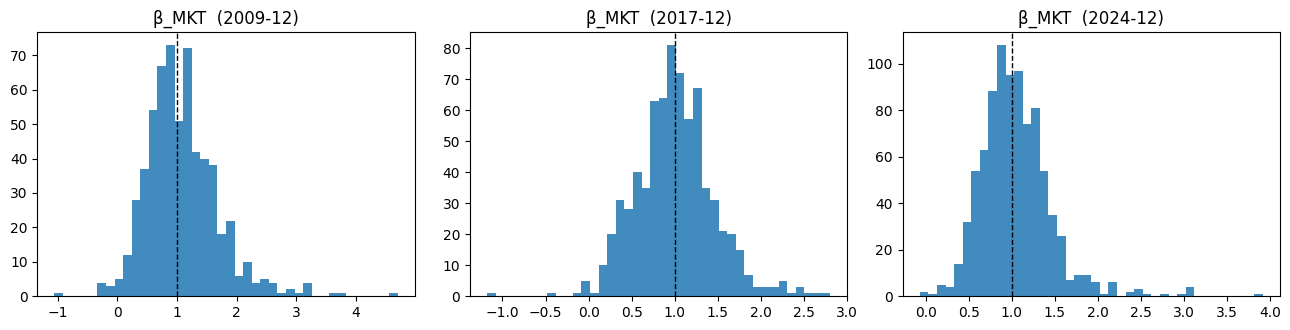

Medijan/IQR β_MKT po prozoru:
                median       std  count
train_window                           
2009-12       1.007384  0.614113    607
2010-12       0.951661  0.537528    626
2011-12       0.986124  0.524980    646
2012-12       0.969802  0.525666    659
2013-12       0.979144  0.448780    664
2014-12       0.988648  0.462393    679
2015-12       0.993681  0.462059    695
2016-12       0.963264  0.434849    708
2017-12       0.991331  0.453551    727
2018-12       1.005088  0.437301    755
2019-12       0.993797  0.443394    773
2020-12       0.975947  0.469923    809
2021-12       0.963622  0.433880    828
2022-12       0.975363  0.398133    841
2023-12       1.010939  0.391986    861
2024-12       0.998629  0.414663    884


In [7]:
# Provjera razdiobi beta po prozoru.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
sample_windows = [windows[0].label, windows[len(windows) // 2].label, windows[-1].label]
for ax, win in zip(axes, sample_windows):
    subset = factor_exposures.loc[factor_exposures["train_window"] == win, "beta_mkt"]
    ax.hist(subset, bins=40, color="C0", alpha=0.85)
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"β_MKT  ({win})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_beta_mkt_histograms.png", dpi=150)
plt.show()

print("Medijan/IQR β_MKT po prozoru:")
medians = factor_exposures.groupby("train_window")["beta_mkt"].agg(["median", "std", "count"])
print(medians)


β_MKT bi se trebao grupirati oko 1 (to je beta na tržišni faktor); SMB i HML
trebali bi obuhvaćati oba predznaka. Ako je razdioba nekog prozora degenerirana, univerzum
u tom prozoru je sumnjiv i treba ga ponovno provjeriti.
